# Saliency Analysis of DP-VAE Synthetic CIFAR-10 Images

**Goal:** Use Integrated Gradients to visualize which pixels in synthetic CIFAR-10
images retain useful class information under different privacy budgets.

**Setup:**
1. Train a CNN classifier on **real** CIFAR-10 (high accuracy baseline)
2. Generate synthetic images: `n_real=600`, conditions: no-DP, ε=8, ε=1
3. Run IG saliency on real + synthetic images
4. Compare: real → no-DP → ε=8 → ε=1 degradation
5. Measure downstream utility (train on synthetic, test on real)

In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

ROOT = Path.cwd()
if not (ROOT / "models").exists() and (ROOT.parent / "models").exists():
    ROOT = ROOT.parent
if not (ROOT / "models").exists() and (ROOT.parent.parent / "models").exists():
    ROOT = ROOT.parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.cifar.cifar_cnn import CIFAR_CNN
from models.cifar.train_cifar_vae import train_cifar_vae_dp

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

<repo>/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Load Real CIFAR-10 & Train Classifier

In [2]:
IMG_SIZE = 32

transform = transforms.Compose([
    transforms.ToTensor(),
])

cifar_train = datasets.CIFAR10(root=ROOT / "data", train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root=ROOT / "data", train=False, download=True, transform=transform)

train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True)
test_loader = DataLoader(cifar_test, batch_size=256, shuffle=False)

print(f"Train: {len(cifar_train)}, Test: {len(cifar_test)}")

Train: 50000, Test: 10000


In [3]:
# Train classifier on real CIFAR-10 (more epochs needed than MNIST)
clf = CIFAR_CNN().to(device)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)

clf.train()
for epoch in range(20):
    correct, total = 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(clf(x), y)
        loss.backward()
        optimizer.step()
        correct += (clf(x).argmax(1) == y).sum().item()
        total += y.size(0)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 — train acc: {correct/total:.4f}")

# Evaluate
clf.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (clf(x).argmax(1) == y).sum().item()
        total += y.size(0)
print(f"\nTest accuracy: {correct/total:.4f}")

Epoch 5/20 — train acc: 0.7615
Epoch 10/20 — train acc: 0.8811
Epoch 15/20 — train acc: 0.9376
Epoch 20/20 — train acc: 0.9580

Test accuracy: 0.7665


## 2. Generate Synthetic Images (n_real=600)

In [4]:
from opacus.accountants.utils import get_noise_multiplier

# Build real data pool
all_images = torch.stack([cifar_train[i][0] for i in range(len(cifar_train))])
all_labels = torch.tensor([cifar_train[i][1] for i in range(len(cifar_train))], dtype=torch.long)

real_by_label = {}
for lbl in range(10):
    real_by_label[lbl] = all_images[all_labels == lbl]

N_REAL = 2000
BATCH_SIZE = 64
EPOCHS = 50
LATENT_DIM = 64
DELTA = 1e-5

# Subsample n_real per label
sub_imgs, sub_lbls = [], []
for lbl in range(10):
    pool = real_by_label[lbl]
    perm = torch.randperm(pool.shape[0])[:N_REAL]
    sub_imgs.append(pool[perm])
    sub_lbls.append(torch.full((N_REAL,), lbl, dtype=torch.long))
data_tensor = torch.cat(sub_imgs, dim=0)
label_tensor = torch.cat(sub_lbls, dim=0)

def get_noise_mult(target_eps):
    if target_eps is None:
        return 0.0
    sr = min(BATCH_SIZE / N_REAL, 0.99)
    return float(get_noise_multiplier(
        target_epsilon=float(target_eps), target_delta=DELTA,
        sample_rate=sr, epochs=EPOCHS,
    ))

CONDITIONS = [
    ("no-DP", None),
    ("ε=8", 8.0),
    ("ε=1", 1.0),
]

synthetic_cache = {}
for label, target_eps in CONDITIONS:
    nm = get_noise_mult(target_eps)
    print(f"\n{'='*50}")
    print(f"Generating: {label} (noise_multiplier={nm:.4f})")
    print(f"{'='*50}")
    syn_x, syn_y, metrics, eps_per_label = train_cifar_vae_dp(
        data_tensor=data_tensor, label_tensor=label_tensor,
        epochs=EPOCHS, batch_size=BATCH_SIZE, latent_dim=LATENT_DIM,
        noise_multiplier=nm, max_grad_norm=1.0, kl_warmup=10,
        lr=1e-3, delta=DELTA, img_size=IMG_SIZE,
        scale_syn=False, synthetic_count=200, seed=SEED,
        eval_metrics=False,
    )
    synthetic_cache[label] = (syn_x, syn_y)
    print(f"  Generated {syn_x.shape[0]} synthetic images.")

print("\nDone generating all conditions.")


Generating: no-DP (noise_multiplier=0.0000)
[CIFAR10-DP-FedAug] Found labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[CIFAR10-DP-FedAug] Label 0: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 0 complete. ε=∞
[CIFAR10-DP-FedAug] Label 1: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 1 complete. ε=∞
[CIFAR10-DP-FedAug] Label 2: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 2 complete. ε=∞
[CIFAR10-DP-FedAug] Label 3: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 3 complete. ε=∞
[CIFAR10-DP-FedAug] Label 4: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 4 complete. ε=∞
[CIFAR10-DP-FedAug] Label 5: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 5 complete. ε=∞
[CIFAR10-DP-FedAug] Label 6: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 6 complete. ε=∞
[CIFAR10-DP-FedAug] Label 7: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 7 complete. ε=∞
[CIFAR10-DP-FedAug] Label 8: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 8 complete. ε=∞
[CIFAR10

<repo>/.venv/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[CIFAR10-DP-FedAug] Label 0 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 1: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 1 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 2: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 2 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 3: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 3 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 4: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 4 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 5: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 5 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 6: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 6 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 7: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 7 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 8: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 8 complete. ε=7.24
[CIFAR10-DP-FedAug] Label 9: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 9 complete. ε=7.24
  Generated 2000 synthetic images.

Generating

<repo>/.venv/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


[CIFAR10-DP-FedAug] Label 0 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 1: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 1 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 2: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 2 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 3: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 3 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 4: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 4 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 5: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 5 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 6: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 6 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 7: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 7 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 8: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 8 complete. ε=0.91
[CIFAR10-DP-FedAug] Label 9: 2000 real -> 200 synthetic
[CIFAR10-DP-FedAug] Label 9 complete. ε=0.91
  Generated 2000 synthetic images.

Done gener

## 3. Saliency Helpers

In [5]:
ig = IntegratedGradients(clf)


def compute_ig(img_tensor, target_label):
    """Compute Integrated Gradients attribution for a single RGB image."""
    img = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    baseline = torch.zeros_like(img)
    attr = ig.attribute(img, baselines=baseline, target=target_label, n_steps=50)
    # Sum over channels to get (H, W) and take absolute value
    return attr.squeeze().detach().cpu().abs().sum(dim=0).numpy()


def normalize_attr(attr):
    """Min-max normalize attribution map to [0, 1]."""
    vmin, vmax = attr.min(), attr.max()
    if vmax - vmin < 1e-8:
        return np.zeros_like(attr)
    return (attr - vmin) / (vmax - vmin)

## 4. Saliency Comparison Grid

For selected classes, show:
- Row per condition: Real | no-DP | ε=8 | ε=1
- Columns: original image, IG overlay

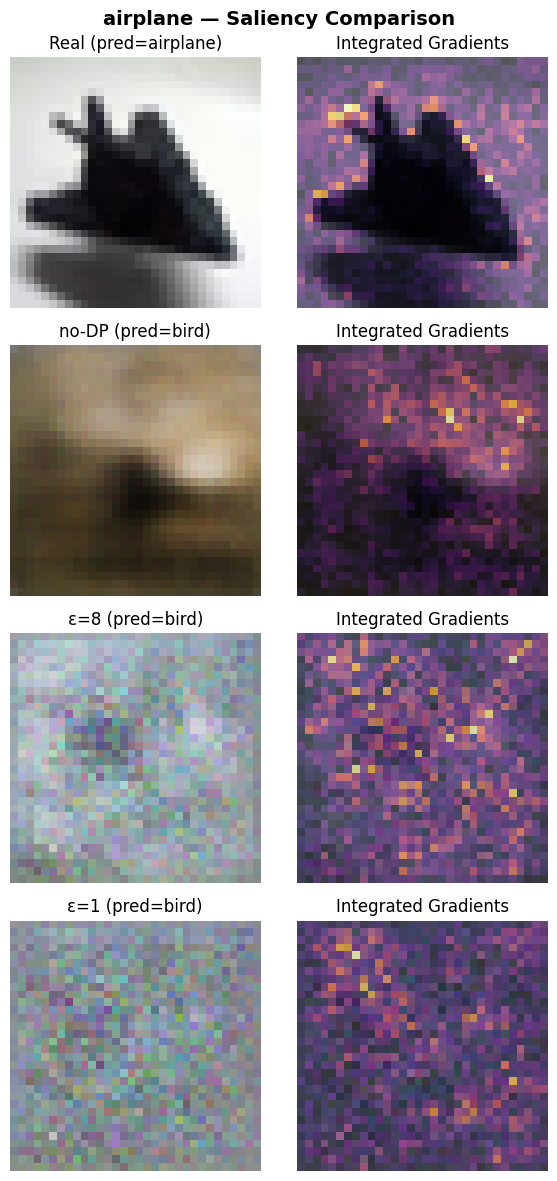

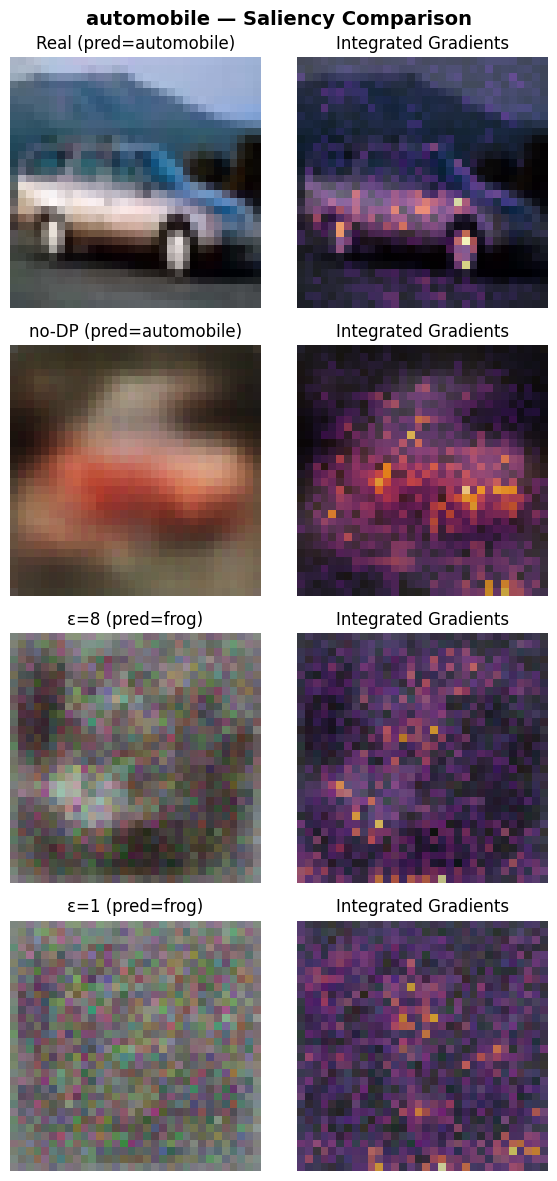

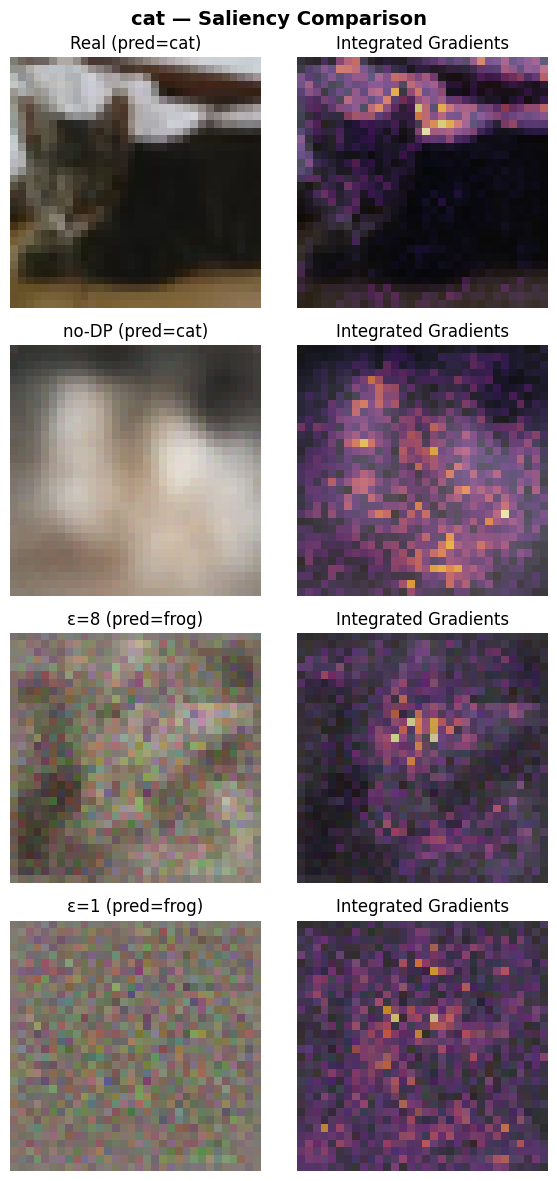

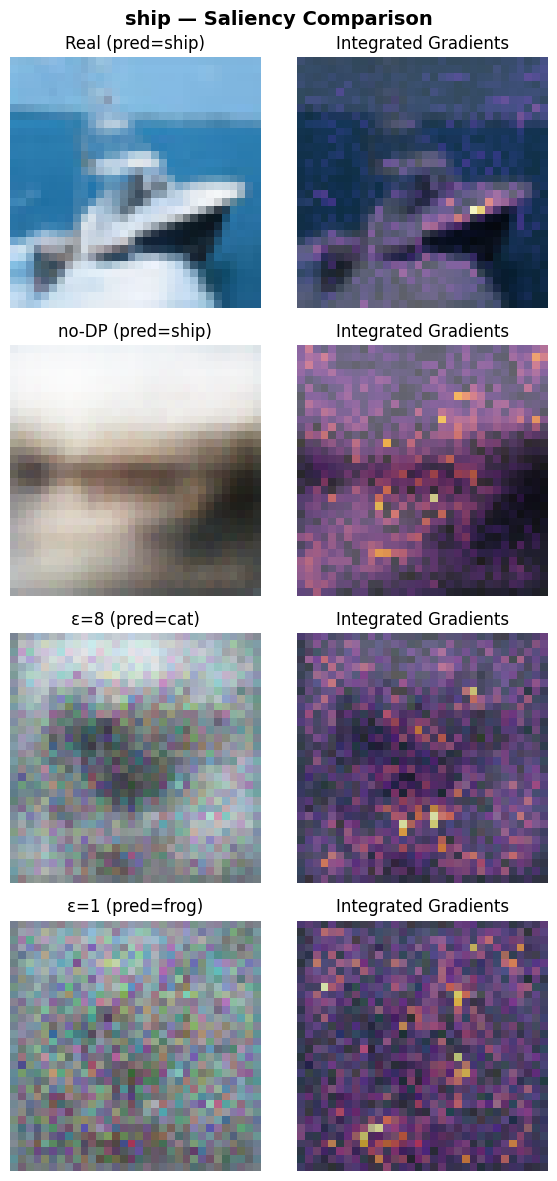

Saved per-class saliency PDFs.


In [6]:
SHOW_LABELS = [0, 1, 3, 8]  # airplane, automobile, cat, ship
COND_NAMES = ["Real", "no-DP", "ε=8", "ε=1"]

clf.eval()

for cls_idx in SHOW_LABELS:
    fig, axes = plt.subplots(len(COND_NAMES), 2, figsize=(6, 3 * len(COND_NAMES)))
    fig.suptitle(f"{CLASS_NAMES[cls_idx]} — Saliency Comparison", fontsize=14, fontweight="bold")

    for row_idx, cond_name in enumerate(COND_NAMES):
        if cond_name == "Real":
            pool = all_images[all_labels == cls_idx]
        else:
            syn_x, syn_y = synthetic_cache[cond_name]
            pool = syn_x[syn_y == cls_idx]

        img = pool[0]
        img_np = img.permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)

        with torch.no_grad():
            pred = clf(img.unsqueeze(0).to(device)).argmax(1).item()

        ig_attr = normalize_attr(compute_ig(img, cls_idx))

        # Col 0: Original image
        ax = axes[row_idx, 0]
        ax.imshow(np.clip(img_np, 0, 1))
        ax.set_title(f"{cond_name} (pred={CLASS_NAMES[pred]})")
        ax.axis("off")

        # Col 1: IG overlay
        ax = axes[row_idx, 1]
        ax.imshow(np.clip(img_np, 0, 1))
        ax.imshow(ig_attr, cmap="inferno", alpha=0.6, vmin=0, vmax=1)
        ax.set_title("Integrated Gradients")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(ROOT / "visual" / "outputs" / f"cifar_saliency_{CLASS_NAMES[cls_idx]}.pdf",
                bbox_inches="tight", dpi=150)
    plt.show()

print("Saved per-class saliency PDFs.")

## 5. Aggregated Saliency Overview (All Classes)

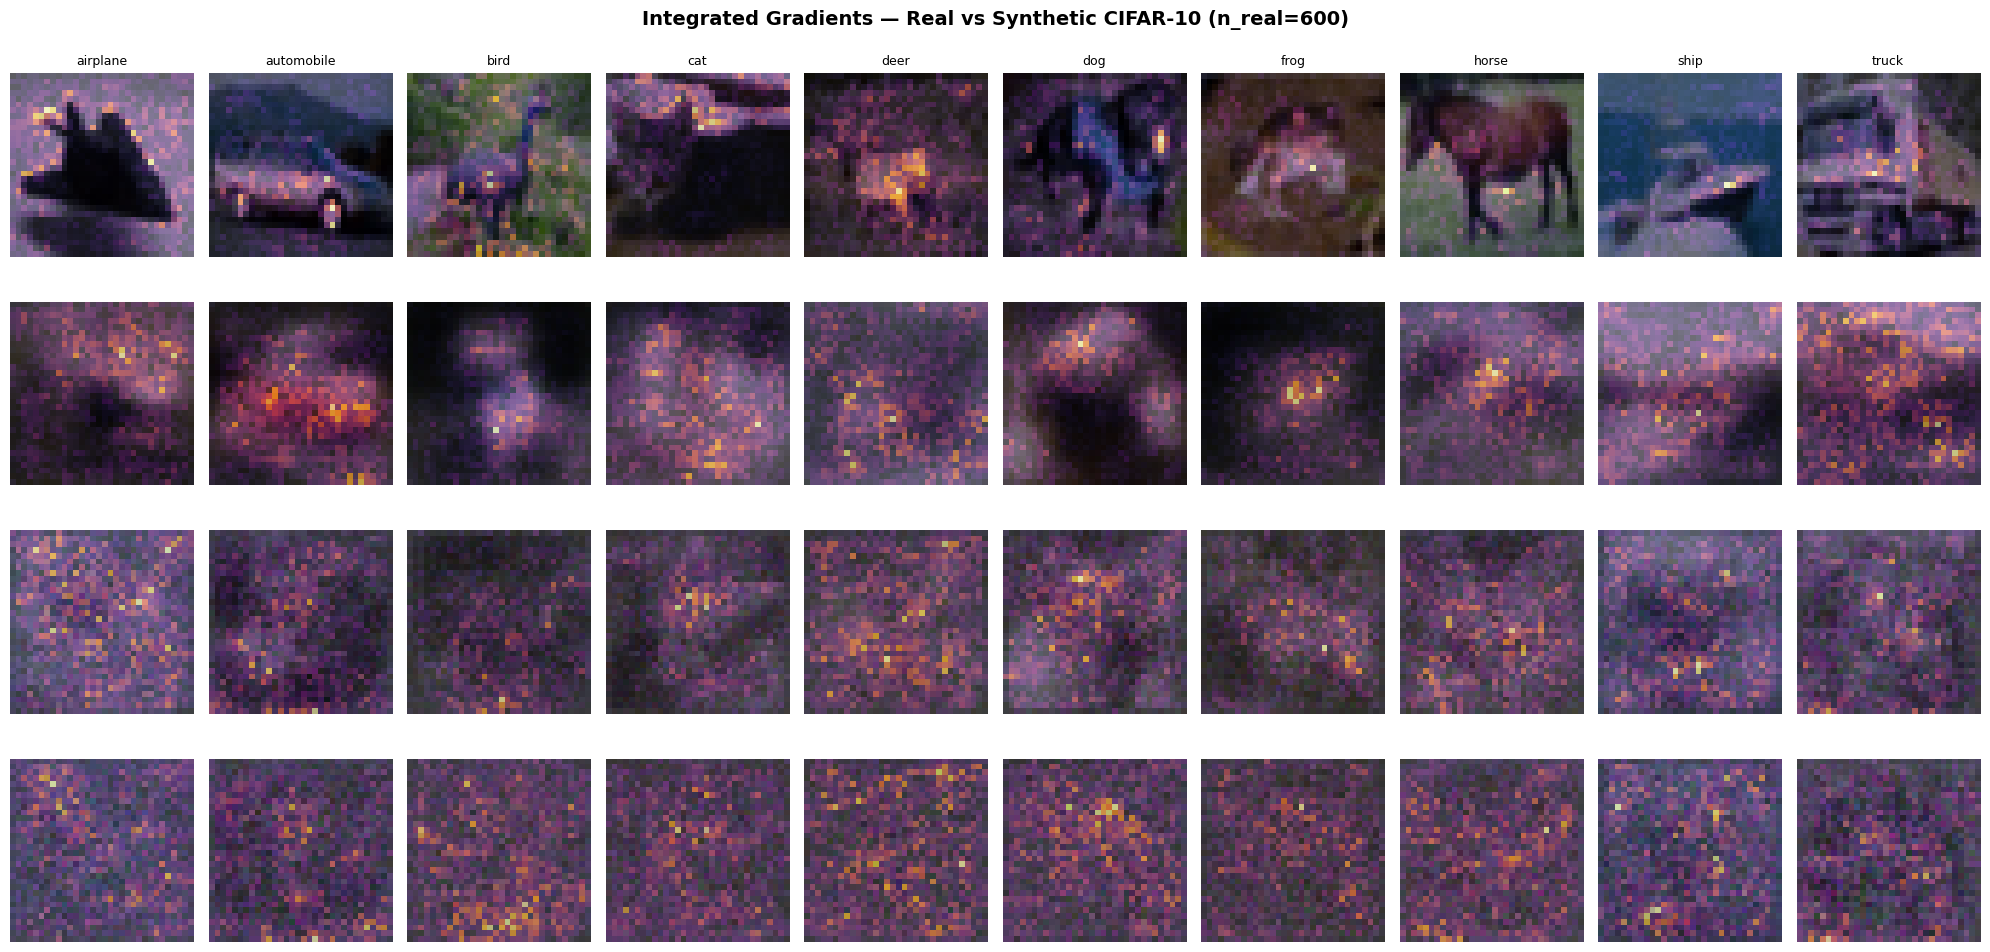

In [7]:
fig, axes = plt.subplots(len(COND_NAMES), 10, figsize=(2 * 10, 2.5 * len(COND_NAMES)))
fig.suptitle("Integrated Gradients — Real vs Synthetic CIFAR-10 (n_real=600)",
             fontsize=14, fontweight="bold")

ROW_LABELS = ["Real", "Synthetic\n(no DP)", "Synthetic\n(ε = 8)", "Synthetic\n(ε = 1)"]

for row_idx, cond_name in enumerate(COND_NAMES):
    for col_idx in range(10):
        if cond_name == "Real":
            pool = all_images[all_labels == col_idx]
        else:
            syn_x, syn_y = synthetic_cache[cond_name]
            pool = syn_x[syn_y == col_idx]

        img = pool[0]
        img_np = img.permute(1, 2, 0).numpy()
        attr = normalize_attr(compute_ig(img, col_idx))

        ax = axes[row_idx, col_idx]
        ax.imshow(np.clip(img_np, 0, 1))
        ax.imshow(attr, cmap="inferno", alpha=0.55, vmin=0, vmax=1)
        ax.axis("off")

        if row_idx == 0:
            ax.set_title(CLASS_NAMES[col_idx], fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(ROW_LABELS[row_idx], fontsize=10, rotation=0, labelpad=50, va="center")

plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "cifar_saliency_overview.pdf",
            bbox_inches="tight", dpi=150)
plt.show()

## 6. Classifier Confidence on Synthetic Data

 no-DP: acc=0.3610, mean_conf=0.3577, median_conf=0.0989
   ε=8: acc=0.2055, mean_conf=0.1937, median_conf=0.0006
   ε=1: acc=0.1120, mean_conf=0.1048, median_conf=0.0000


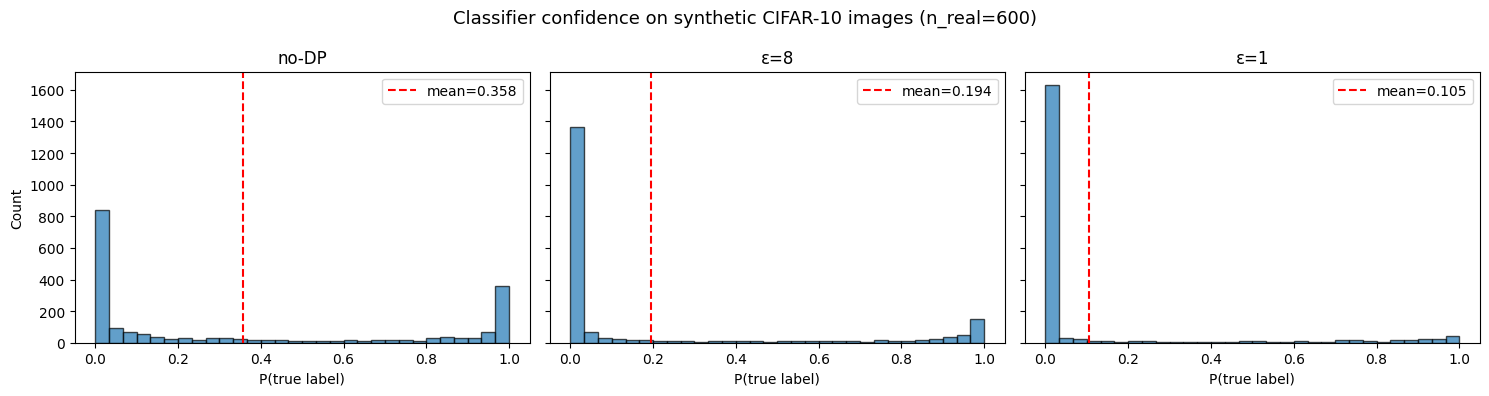

In [8]:
clf.eval()

for cond_name in ["no-DP", "ε=8", "ε=1"]:
    syn_x, syn_y = synthetic_cache[cond_name]
    with torch.no_grad():
        logits = clf(syn_x.to(device))
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(1).cpu()
        true_conf = probs[torch.arange(len(syn_y)), syn_y].cpu()
        acc = (preds == syn_y).float().mean().item()
    print(f"{cond_name:>6s}: acc={acc:.4f}, mean_conf={true_conf.mean():.4f}, median_conf={true_conf.median():.4f}")

# Confidence distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cond_name in zip(axes, ["no-DP", "ε=8", "ε=1"]):
    syn_x, syn_y = synthetic_cache[cond_name]
    with torch.no_grad():
        probs = F.softmax(clf(syn_x.to(device)), dim=1)
        true_conf = probs[torch.arange(len(syn_y)), syn_y].cpu().numpy()
    ax.hist(true_conf, bins=30, range=(0, 1), edgecolor="black", alpha=0.7)
    ax.set_title(f"{cond_name}")
    ax.set_xlabel("P(true label)")
    ax.axvline(np.mean(true_conf), color="red", linestyle="--", label=f"mean={np.mean(true_conf):.3f}")
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Classifier confidence on synthetic CIFAR-10 images (n_real=600)", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "cifar_confidence_hist.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 7. Mean Saliency Maps (Averaged Over All Samples)

Average Integrated Gradients attribution across all synthetic images per condition to show
how DP noise systematically degrades the spatial signal that the classifier relies on.

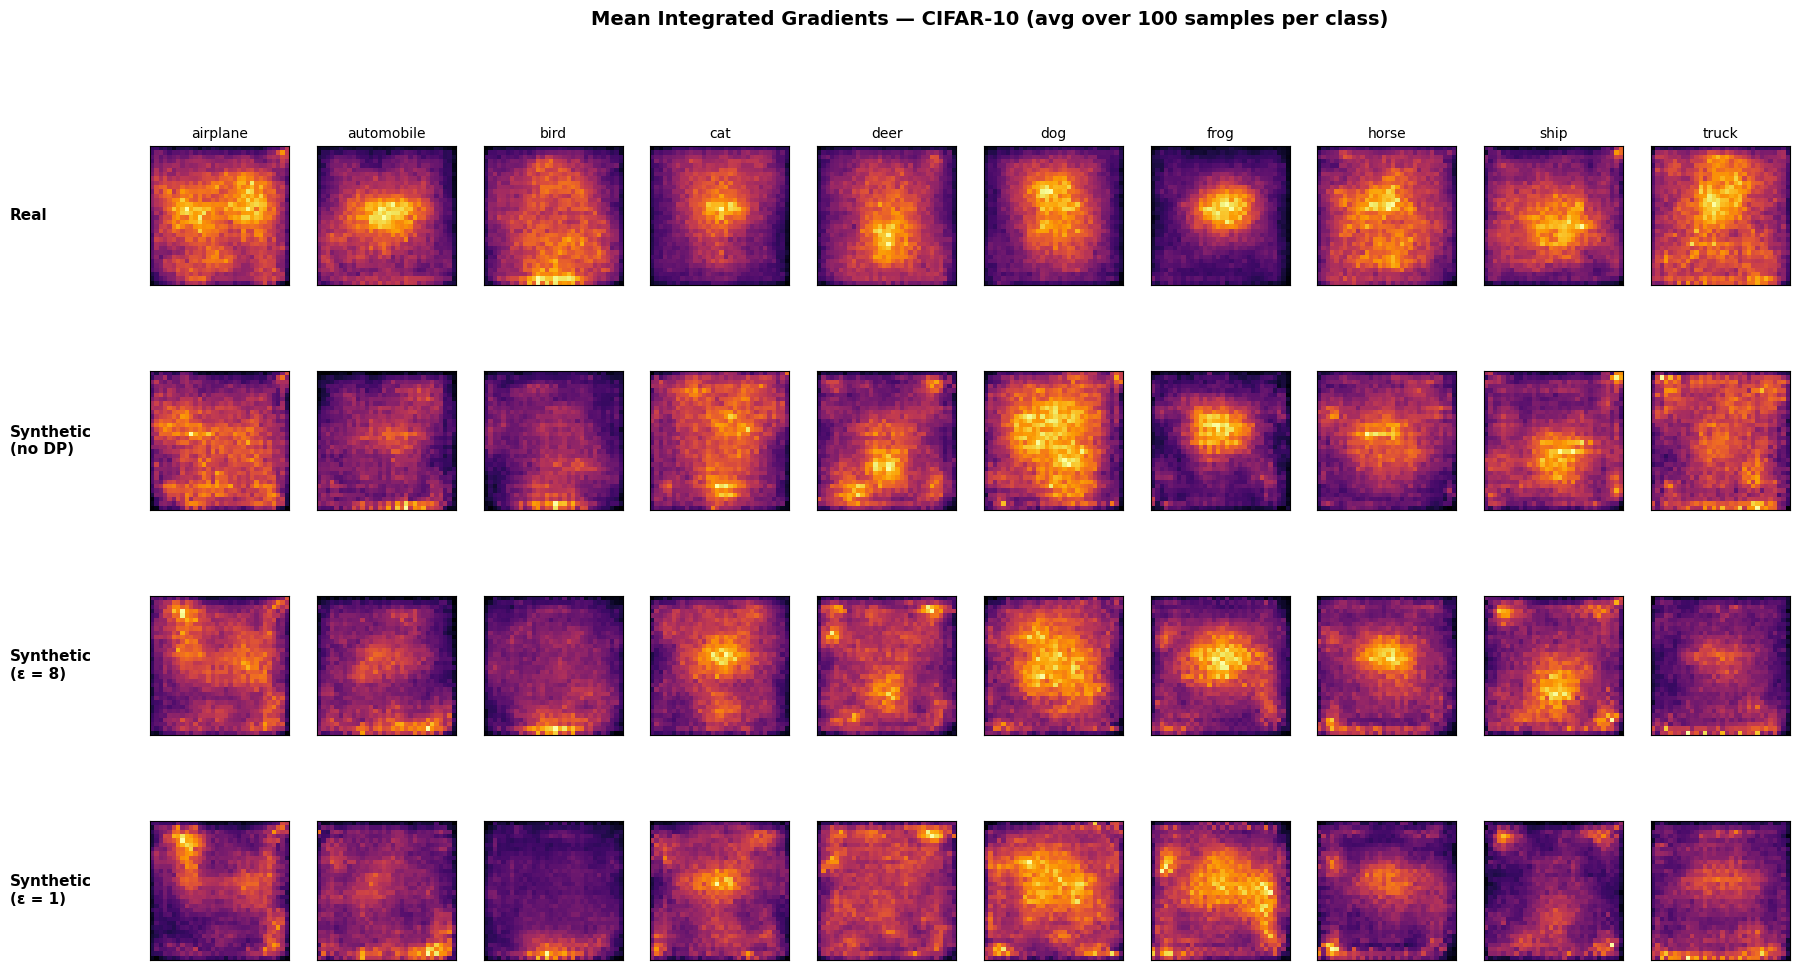

Saved mean IG saliency map.


In [9]:
N_SAMPLES = 100  # average over this many per class

ROW_LABELS = ["Real", "Synthetic\n(no DP)", "Synthetic\n(ε = 8)", "Synthetic\n(ε = 1)"]

fig, axes = plt.subplots(
    len(COND_NAMES), 10,
    figsize=(20, 2.8 * len(COND_NAMES)),
    gridspec_kw={"left": 0.08},
)
fig.suptitle(
    f"Mean Integrated Gradients — CIFAR-10 (avg over {N_SAMPLES} samples per class)",
    fontsize=14, fontweight="bold", y=0.98,
)

for row_idx, cond_name in enumerate(COND_NAMES):
    for cls_idx in range(10):
        if cond_name == "Real":
            pool = all_images[all_labels == cls_idx]
        else:
            syn_x, syn_y = synthetic_cache[cond_name]
            pool = syn_x[syn_y == cls_idx]

        n = min(N_SAMPLES, pool.shape[0])
        attrs = []
        for i in range(n):
            attrs.append(compute_ig(pool[i], cls_idx))
        mean_attr = normalize_attr(np.mean(attrs, axis=0))

        ax = axes[row_idx, cls_idx]
        ax.imshow(mean_attr, cmap="inferno", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=10)

    # Row label
    bbox = axes[row_idx, 0].get_position()
    fig.text(
        0.01, (bbox.y0 + bbox.y1) / 2, ROW_LABELS[row_idx],
        fontsize=11, fontweight="bold", va="center", ha="left",
    )

plt.savefig(ROOT / "visual" / "outputs" / "cifar_saliency_mean_ig.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved mean IG saliency map.")

## 8. Downstream Utility: Train on Synthetic, Test on Real

**The metric that actually matters for DP-FedAug:** If a classifier trained *only* on
synthetic data can still classify real test images, the synthetic data retains useful
information — even if it looks noisy or fails fidelity metrics.

We test:
- **Synthetic-only** classifiers
- **Augmented** (few real + synthetic) to simulate data-scarce clients
- **Extreme heterogeneity** (single-class client)

In [10]:
def train_and_eval(train_x, train_y, test_loader, epochs=15, lr=1e-3):
    """Train a fresh CIFAR_CNN and return test accuracy."""
    model = CIFAR_CNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ds = TensorDataset(train_x, train_y)
    dl = DataLoader(ds, batch_size=64, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            F.cross_entropy(model(xb), yb).backward()
            opt.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total


# ── 8a. Synthetic-only classifiers ──────────────────────────────────
print("=" * 60)
print("SYNTHETIC-ONLY: Train classifier on synthetic data, test on real")
print("=" * 60)

syn_only_results = {}
for cond_name in ["no-DP", "ε=8", "ε=1"]:
    syn_x, syn_y = synthetic_cache[cond_name]
    acc = train_and_eval(syn_x, syn_y, test_loader, epochs=15)
    syn_only_results[cond_name] = acc
    print(f"  {cond_name:>6s}-only → test acc: {acc:.4f}")

real_acc = train_and_eval(data_tensor, label_tensor, test_loader, epochs=15)
syn_only_results["Real (600/cls)"] = real_acc
print(f"  {'Real':>6s} (600/class) → test acc: {real_acc:.4f}")


# ── 8b. Augmented classifiers (real + synthetic) ───────────────────
print(f"\n{'=' * 60}")
print("AUGMENTED: Few real samples + synthetic augmentation")
print("=" * 60)

aug_results = []
for n_real_local in [10, 50, 100]:
    local_imgs, local_lbls = [], []
    for lbl in range(10):
        pool = real_by_label[lbl]
        perm = torch.randperm(pool.shape[0])[:n_real_local]
        local_imgs.append(pool[perm])
        local_lbls.append(torch.full((n_real_local,), lbl, dtype=torch.long))
    local_x = torch.cat(local_imgs)
    local_y = torch.cat(local_lbls)

    acc_real = train_and_eval(local_x, local_y, test_loader, epochs=15)
    aug_results.append({"n_real": n_real_local, "condition": "Real only", "acc": acc_real})
    print(f"\n  n_real={n_real_local}/class:")
    print(f"    Real only           → {acc_real:.4f}")

    for cond_name in ["no-DP", "ε=8", "ε=1"]:
        syn_x, syn_y = synthetic_cache[cond_name]
        aug_x = torch.cat([local_x, syn_x])
        aug_y = torch.cat([local_y, syn_y])
        acc_aug = train_and_eval(aug_x, aug_y, test_loader, epochs=15)
        aug_results.append({"n_real": n_real_local, "condition": f"+ {cond_name} syn", "acc": acc_aug})
        delta_pct = (acc_aug - acc_real) * 100
        arrow = "↑" if delta_pct > 0 else "↓"
        print(f"    + {cond_name:>5s} synthetic → {acc_aug:.4f}  ({arrow}{abs(delta_pct):.1f}pp)")

SYNTHETIC-ONLY: Train classifier on synthetic data, test on real
   no-DP-only → test acc: 0.3683
     ε=8-only → test acc: 0.2342
     ε=1-only → test acc: 0.2244
    Real (600/class) → test acc: 0.7062

AUGMENTED: Few real samples + synthetic augmentation

  n_real=10/class:
    Real only           → 0.2482
    + no-DP synthetic → 0.4045  (↑15.6pp)
    +   ε=8 synthetic → 0.2646  (↑1.6pp)
    +   ε=1 synthetic → 0.2738  (↑2.6pp)

  n_real=50/class:
    Real only           → 0.3898
    + no-DP synthetic → 0.4195  (↑3.0pp)
    +   ε=8 synthetic → 0.3252  (↓6.5pp)
    +   ε=1 synthetic → 0.3723  (↓1.7pp)

  n_real=100/class:
    Real only           → 0.4256
    + no-DP synthetic → 0.5035  (↑7.8pp)
    +   ε=8 synthetic → 0.3708  (↓5.5pp)
    +   ε=1 synthetic → 0.4048  (↓2.1pp)


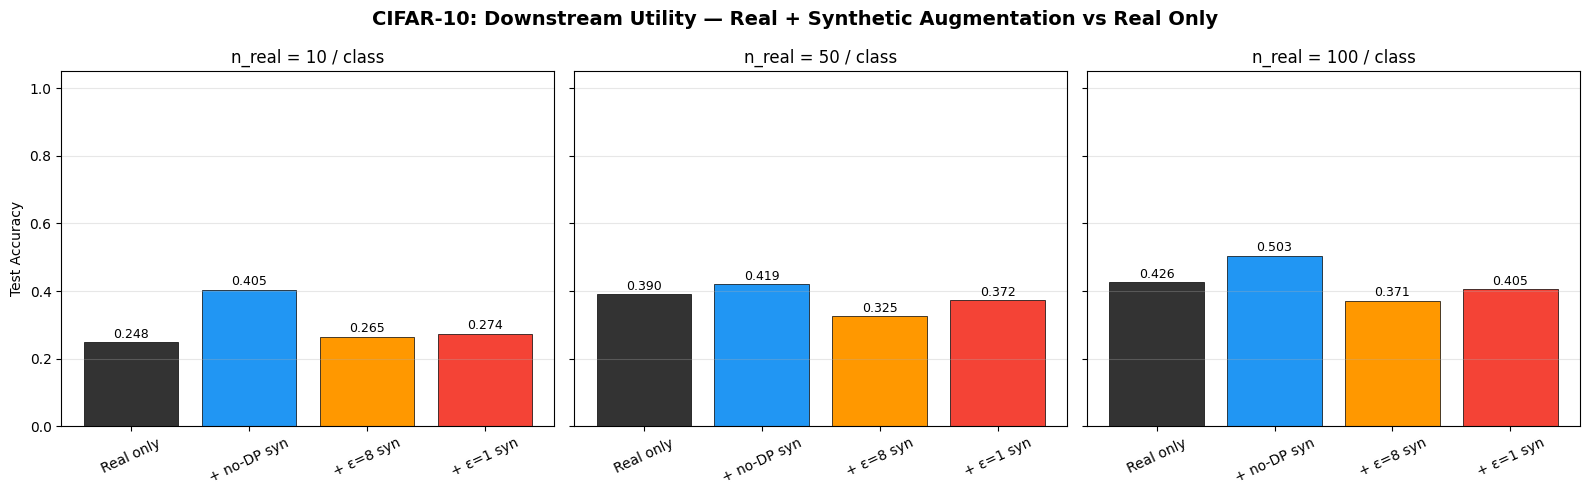

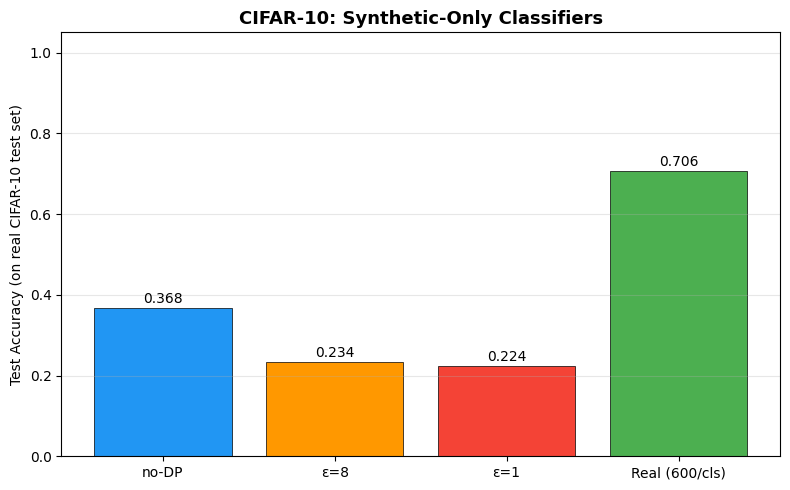


Saved downstream utility plots.


In [11]:
# ── 8c. Visualization ───────────────────────────────────────────────
import pandas as pd

aug_df = pd.DataFrame(aug_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax_idx, n_real_local in enumerate([10, 50, 100]):
    ax = axes[ax_idx]
    subset = aug_df[aug_df["n_real"] == n_real_local]

    colors = {"Real only": "#333333", "+ no-DP syn": "#2196F3", "+ ε=8 syn": "#FF9800", "+ ε=1 syn": "#F44336"}
    bars = ax.bar(subset["condition"], subset["acc"], color=[colors[c] for c in subset["condition"]],
                  edgecolor="black", linewidth=0.5)

    for bar, val in zip(bars, subset["acc"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"n_real = {n_real_local} / class", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test Accuracy" if ax_idx == 0 else "")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("CIFAR-10: Downstream Utility — Real + Synthetic Augmentation vs Real Only",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "cifar_downstream_utility.pdf", bbox_inches="tight", dpi=150)
plt.show()

# ── 8d. Synthetic-only bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
names = list(syn_only_results.keys())
accs = list(syn_only_results.values())
colors_syn = ["#2196F3", "#FF9800", "#F44336", "#4CAF50"]
bars = ax.bar(names, accs, color=colors_syn, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Test Accuracy (on real CIFAR-10 test set)")
ax.set_title("CIFAR-10: Synthetic-Only Classifiers", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "cifar_synonly_utility.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("\nSaved downstream utility plots.")

## 9. Extreme Heterogeneity Simulation

Client has data from only 1 class (airplane, 60 samples), then receives
200 synthetic samples per class from the server (covering all 10 classes).

Local only (airplane, n=60): test acc = 0.1000
  (Expected ~10% since it can only predict class 0)

+ no-DP synthetic: test acc = 0.2772  (↑17.7pp vs local-only)
+   ε=8 synthetic: test acc = 0.1574  (↑5.7pp vs local-only)
+   ε=1 synthetic: test acc = 0.1310  (↑3.1pp vs local-only)


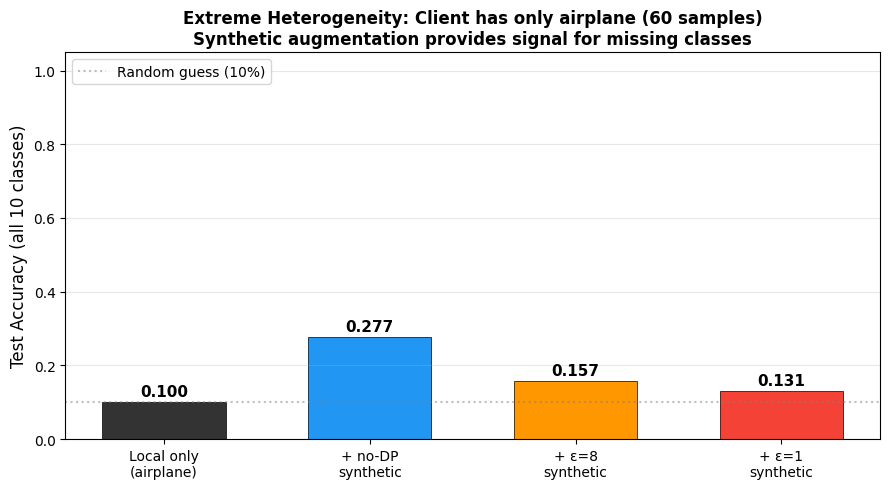


This demonstrates whether DP-FedAug provides value on CIFAR-10
despite the harder generation task compared to MNIST.


In [12]:
extreme_results = []
CLIENT_CLASS = 0  # airplane
N_LOCAL = 60

local_x = real_by_label[CLIENT_CLASS][:N_LOCAL]
local_y = torch.full((N_LOCAL,), CLIENT_CLASS, dtype=torch.long)

acc_local = train_and_eval(local_x, local_y, test_loader, epochs=15)
extreme_results.append((f"Local only\n({CLASS_NAMES[CLIENT_CLASS]})", acc_local))
print(f"Local only ({CLASS_NAMES[CLIENT_CLASS]}, n={N_LOCAL}): test acc = {acc_local:.4f}")
print(f"  (Expected ~10% since it can only predict class {CLIENT_CLASS})\n")

for cond_name in ["no-DP", "ε=8", "ε=1"]:
    syn_x, syn_y = synthetic_cache[cond_name]
    aug_x = torch.cat([local_x, syn_x])
    aug_y = torch.cat([local_y, syn_y])
    acc_aug = train_and_eval(aug_x, aug_y, test_loader, epochs=15)
    extreme_results.append((f"+ {cond_name}\nsynthetic", acc_aug))
    delta = (acc_aug - acc_local) * 100
    print(f"+ {cond_name:>5s} synthetic: test acc = {acc_aug:.4f}  (↑{delta:.1f}pp vs local-only)")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
names = [r[0] for r in extreme_results]
accs = [r[1] for r in extreme_results]
colors_ext = ["#333333", "#2196F3", "#FF9800", "#F44336"]
bars = ax.bar(names, accs, color=colors_ext, edgecolor="black", linewidth=0.5, width=0.6)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Test Accuracy (all 10 classes)", fontsize=12)
ax.set_title(
    f"Extreme Heterogeneity: Client has only {CLASS_NAMES[CLIENT_CLASS]} ({N_LOCAL} samples)\n"
    "Synthetic augmentation provides signal for missing classes",
    fontsize=12, fontweight="bold"
)
ax.set_ylim(0, 1.05)
ax.axhline(0.1, color="gray", linestyle=":", alpha=0.5, label="Random guess (10%)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "cifar_extreme_hetero.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("\nThis demonstrates whether DP-FedAug provides value on CIFAR-10")
print("despite the harder generation task compared to MNIST.")